Let's break down confidence intervals with opinion polls simply and then dive into some Python fun!

What's a Confidence Interval? 🤔
Imagine you want to know how many high schoolers prefer pizza over burgers. You can't ask every single high schooler in the world, right? That would take forever! So, you take a sample – maybe ask 100 high schoolers.

Let's say in your sample of 100, 60% say they prefer pizza. Now, you might think, "Great! 60% of all high schoolers prefer pizza." But is it exactly 60%? Probably not. Your sample is just a snapshot.

A confidence interval is like saying, "We're pretty sure the true percentage of all high schoolers who prefer pizza is somewhere between X% and Y%." It gives you a range, not just a single number.

Think of it like this: You throw a dart at a dartboard. You might not hit the bullseye every time, but you can say, "I'm 95% confident my dart will land within this big circle around the bullseye." The big circle is your confidence interval.

So, for our pizza example, we might say, "We're 95% confident that between 50% and 70% of all high schoolers prefer pizza." This means if we took many, many samples, 95% of the confidence intervals we calculated would contain the true percentage of pizza lovers.

Key takeaway: A confidence interval gives us a range where we're pretty sure the true value lies, based on our sample.

In [45]:
! pip install statsmodels

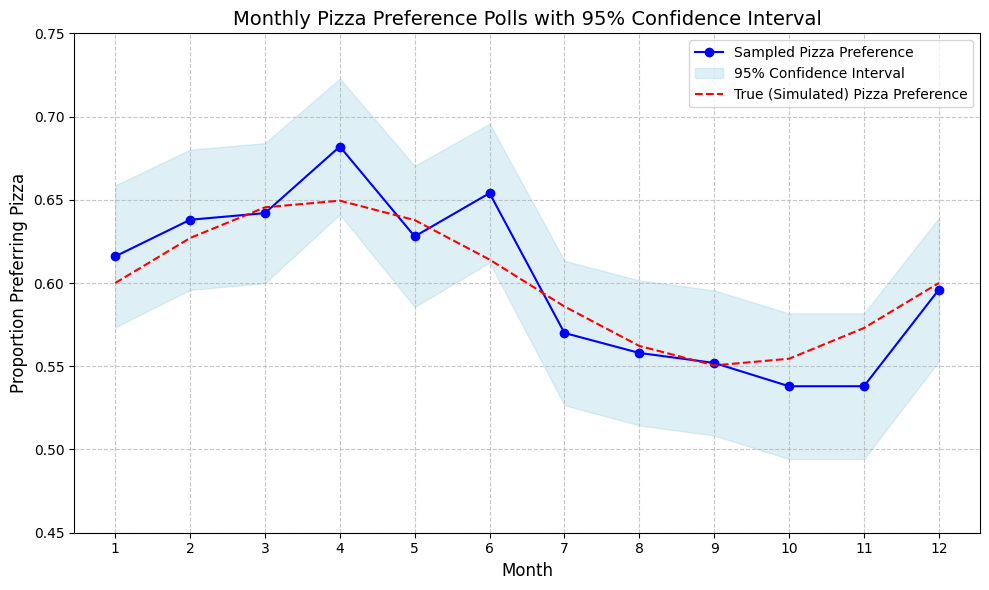

In [46]:
#Python Example: Tracking Pizza Preference Over Time 🍕📈


import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Set a random seed for reproducibility
np.random.seed(42)

# --- Simulate our data ---
# Imagine the true preference for pizza changes a little over time
true_preference = 0.60 + 0.05 * np.sin(np.linspace(0, 2 * np.pi, 12)) # A little wiggle
sample_size = 500 # Number of high schoolers we poll each month

# Simulate monthly poll results
# Number of high schoolers who prefer pizza
pizza_lovers = np.random.binomial(n=sample_size, p=true_preference, size=12)
# Percentage of high schoolers who prefer pizza in our sample
sample_proportion = pizza_lovers / sample_size

# --- Calculate Confidence Intervals ---
# We'll use a 95% confidence level
confidence_level = 0.95

# Calculate the standard error for proportions
# For a proportion p and sample size n, SE = sqrt(p*(1-p)/n)
# We use a Z-score for a 95% confidence level (approx 1.96)
z_score = 1.96 # This value comes from the standard normal distribution

# Calculate lower and upper bounds of the confidence interval
lower_bound = sample_proportion - z_score * np.sqrt(sample_proportion * (1 - sample_proportion) / sample_size)
upper_bound = sample_proportion + z_score * np.sqrt(sample_proportion * (1 - sample_proportion) / sample_size)

# --- Plotting the results ---
months = np.arange(1, 13)

plt.figure(figsize=(10, 6))
plt.plot(months, sample_proportion, marker='o', linestyle='-', color='blue', label='Sampled Pizza Preference')
plt.fill_between(months, lower_bound, upper_bound, color='lightblue', alpha=0.4, label='95% Confidence Interval')
plt.plot(months, true_preference, linestyle='--', color='red', label='True (Simulated) Pizza Preference') # The true value we're trying to estimate

plt.title('Monthly Pizza Preference Polls with 95% Confidence Interval', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Proportion Preferring Pizza', fontsize=12)
plt.xticks(months)
plt.ylim(0.45, 0.75) # Set limits for better visualization
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


Explanation of the Code:

Simulating Data: We create true_preference which is the "real" (but unknown to us in a real scenario) percentage of high schoolers who prefer pizza each month. Then, we simulate taking a sample_size poll each month and getting pizza_lovers results, which gives us our sample_proportion.

Calculating Confidence Interval:

We use a confidence_level of 95%, which is very common.

The z_score of 1.96 is a magic number for 95% confidence (it tells us how many standard deviations away from the mean we need to go to capture 95% of the data).

We calculate the lower_bound and upper_bound of our interval using a formula that involves the sample_proportion, z_score, and sample_size. This formula is based on the idea that our sample proportion is an estimate of the true proportion, and we use the standard error to understand how much that estimate might vary.

Plotting: The blue line shows what our poll actually found each month. The light blue shaded area is our 95% confidence interval for each month. The dashed red line is the "true" preference (which we only know because we simulated it!). Notice how most of the time, the true preference falls within our confidence interval. This shows that the confidence interval is doing its job!

In [47]:
# Hands-On Assignments

# Confidence Interval Assignment 🚀

These assignments will help you get hands-on experience with confidence intervals using the provided Python code. Remember to run the Python code first to generate the plot before starting the assignments.

---

## Assignment 1: The Sample Size Effect 🤔

**Goal:** Understand how the number of people you poll affects your confidence interval.

1.  **Run the Python code above.** Observe the **width** of the light blue shaded area (the confidence interval).
2.  **Change `sample_size` to `100`.** Rerun the code. What happens to the width of the confidence interval? Is it wider or narrower?
3.  **Change `sample_size` to `1000`.** Rerun the code. What happens to the width of the confidence interval now?
4.  **Discuss:** Why do you think increasing the sample size makes the confidence interval narrower? (Hint: Think about how much more certain you'd be if you asked 1000 people versus 100 people about their pizza preference.)

---



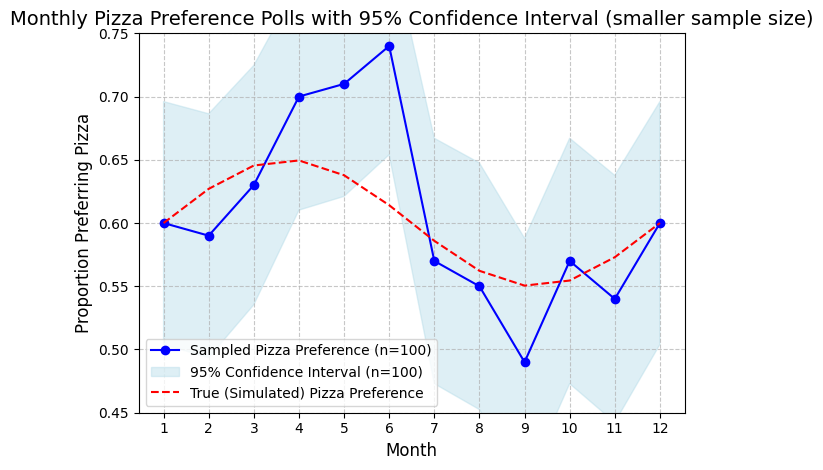

The confidence interval is far wider in this scenario with a low sample size.
In order to be 95% confident, a wider range of values must be taken.
This is because the standard deviation of a sample proportion is calculated by dividing by sample size.
When this decreases, the denominator is smaller and therefore the standard deviation is greater.
When multiplying by the proper z-score for 95th percentile, this will increase the variation from mu.


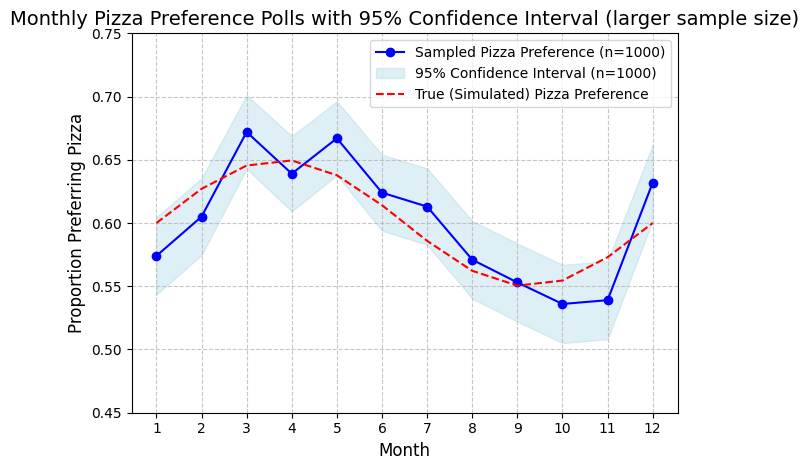

In this case, the samples are more accurate.
For the same reason decreasing sample size reduces accuracy, increasing it has the opposite effect
Additionally, in both scenarios, there is the accuracy of the sample is also dependent on sample size
The standard deviation is an order of magnitude different between the two, leading to the translated difference in both sample size accuracy and confidence interval width
Finally, the only error within the confidence interval is in the sample with the smaller size


In [48]:
np.random.seed(42)
sample_size2 = 100
pizza_lovers2 = np.random.binomial(n=sample_size2, p=true_preference, size=12)
sample_proportion2 = pizza_lovers2 / sample_size2

lower_bound2 = sample_proportion2 - z_score * np.sqrt(sample_proportion2 * (1 - sample_proportion2) / sample_size2)
upper_bound2 = sample_proportion2 + z_score * np.sqrt(sample_proportion2 * (1 - sample_proportion2) / sample_size2)

plt.plot(months, sample_proportion2, marker='o', linestyle='-', color='blue', label='Sampled Pizza Preference (n=100)')
plt.fill_between(months, lower_bound2, upper_bound2, color='lightblue', alpha=0.4, label='95% Confidence Interval (n=100)')
plt.plot(months, true_preference, linestyle='--', color='red', label='True (Simulated) Pizza Preference')

plt.title('Monthly Pizza Preference Polls with 95% Confidence Interval (smaller sample size)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Proportion Preferring Pizza', fontsize=12)
plt.xticks(months)
plt.ylim(0.45, 0.75)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("The confidence interval is far wider in this scenario with a low sample size.")
print("In order to be 95% confident, a wider range of values must be taken.")
print("This is because the standard deviation of a sample proportion is calculated by dividing by sample size.")
print("When this decreases, the denominator is smaller and therefore the standard deviation is greater.")
print("When multiplying by the proper z-score for 95th percentile, this will increase the variation from mu.")


sample_size3 = 1000
pizza_lovers3 = np.random.binomial(n=sample_size3, p=true_preference, size=12)
sample_proportion3 = pizza_lovers3 / sample_size3

lower_bound3 = sample_proportion3 - z_score * np.sqrt(sample_proportion3 * (1 - sample_proportion3) / sample_size3)
upper_bound3 = sample_proportion3 + z_score * np.sqrt(sample_proportion3 * (1 - sample_proportion3) / sample_size3)

plt.plot(months, sample_proportion3, marker='o', linestyle='-', color='blue', label='Sampled Pizza Preference (n=1000)')
plt.fill_between(months, lower_bound3, upper_bound3, color='lightblue', alpha=0.4, label='95% Confidence Interval (n=1000)')
plt.plot(months, true_preference, linestyle='--', color='red', label='True (Simulated) Pizza Preference')

plt.title('Monthly Pizza Preference Polls with 95% Confidence Interval (larger sample size)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Proportion Preferring Pizza', fontsize=12)
plt.xticks(months)
plt.ylim(0.45, 0.75)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print("In this case, the samples are more accurate.")
print("For the same reason decreasing sample size reduces accuracy, increasing it has the opposite effect")
print("Additionally, in both scenarios, there is the accuracy of the sample is also dependent on sample size")
print("The standard deviation is an order of magnitude different between the two, leading to the translated difference in both sample size accuracy and confidence interval width")
print("Finally, the only error within the confidence interval is in the sample with the smaller size")

## Assignment 2: The Confidence Level Effect 🎯

**Goal:** Understand what the "95%" in "95% confident" means.

1.  **Run the original Python code** with `sample_size = 500` and `confidence_level = 0.95`. Note how many of the red dashed line points fall *outside* the blue shaded area.
2.  **Change `z_score` to `2.58`** (which corresponds to a **99% confidence level**). Rerun the code. Observe the interval width.
3.  **Change `z_score` to `1.64`** (which corresponds to a **90% confidence level**). Rerun the code. Observe the interval width.
4.  **Discuss:**
    * When you **increased** the confidence level (e.g., to 99%), what happened to the width of the confidence interval? Why does being *more* confident require a *wider* range?
    * When you **decreased** the confidence level (e.g., to 90%), what happened to the width? What's the **trade-off** here? Would you rather be 99% confident with a very wide range, or 90% confident with a narrower range?

---

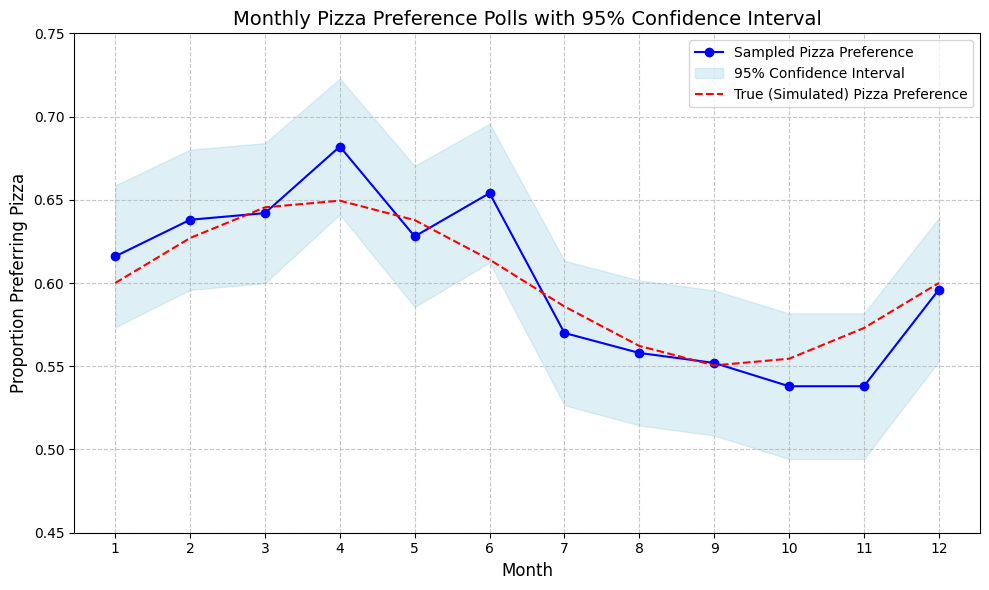

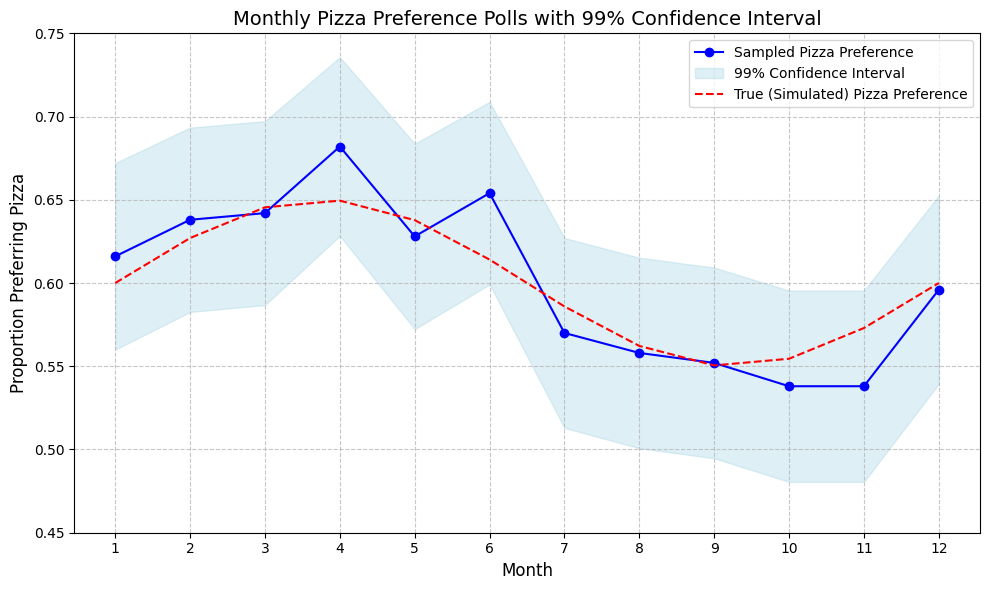

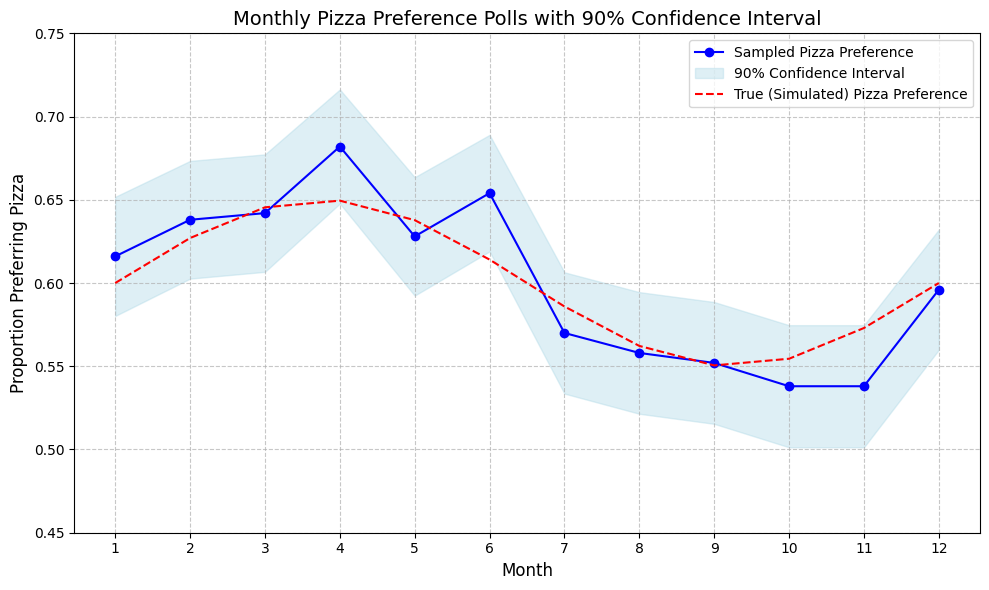

A confidence level of 0.95 has a z_score of 1.96
A confidence level of 0.99 has a z_score of 2.5758293035489004 or approx 2.576
A confidence level of 0.9 has a z_score of 1.6448536269514722 or approx 1.644

Confidence levels are inversely proportional to their width. This is derived from the z-score
Z score is interpreted as the point along the normal distribution where a certain number of area is covered on each side.
For example, we can use a z score of 1.96 (95% confidence). This means the integral from -1.96 to 1.96 is 95% of the area of the normal distribution.
This is the same for the different z scores of 90 and 99 percent confidence respectively. This means that being more confident, and the greater z score that comes along it, has more to capture.
Becuase a confidence of 99 has a higher z score, the standard deviation from the mean is greater, meaning the lower and upper bounds are greater.
In turn, this increases the area of the interval itself.
This logically makes sense. If

In [51]:
from scipy.stats import norm

plt.figure(figsize=(10, 6))
plt.plot(months, sample_proportion, marker='o', linestyle='-', color='blue', label='Sampled Pizza Preference')
plt.fill_between(months, lower_bound, upper_bound, color='lightblue', alpha=0.4, label='95% Confidence Interval')
plt.plot(months, true_preference, linestyle='--', color='red', label='True (Simulated) Pizza Preference') # The true value we're trying to estimate

plt.title('Monthly Pizza Preference Polls with 95% Confidence Interval', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Proportion Preferring Pizza', fontsize=12)
plt.xticks(months)
plt.ylim(0.45, 0.75) # Set limits for better visualization
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

confidence_level2 = 0.99

#using inverse norm function to show z-score calculation for conf=99
z_score99 = norm.ppf(confidence_level2 + (1-confidence_level2)/2)
lower_bound99 = sample_proportion - z_score99 * np.sqrt(sample_proportion * (1 - sample_proportion) / sample_size)
upper_bound99 = sample_proportion + z_score99 * np.sqrt(sample_proportion * (1 - sample_proportion) / sample_size)

plt.figure(figsize=(10, 6))
plt.plot(months, sample_proportion, marker='o', linestyle='-', color='blue', label='Sampled Pizza Preference')
plt.fill_between(months, lower_bound99, upper_bound99, color='lightblue', alpha=0.4, label='99% Confidence Interval')
plt.plot(months, true_preference, linestyle='--', color='red', label='True (Simulated) Pizza Preference')

plt.title('Monthly Pizza Preference Polls with 99% Confidence Interval', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Proportion Preferring Pizza', fontsize=12)
plt.xticks(months)
plt.ylim(0.45, 0.75)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

#condfidence level of 90
confidence_level3 = 0.9
z_score90 = norm.ppf(confidence_level3 + (1-confidence_level3)/2)
lower_bound90 = sample_proportion - z_score90 * np.sqrt(sample_proportion * (1 - sample_proportion) / sample_size)
upper_bound90 = sample_proportion + z_score90 * np.sqrt(sample_proportion * (1 - sample_proportion) / sample_size)

plt.figure(figsize=(10, 6))
plt.plot(months, sample_proportion, marker='o', linestyle='-', color='blue', label='Sampled Pizza Preference')
plt.fill_between(months, lower_bound90, upper_bound90, color='lightblue', alpha=0.4, label='90% Confidence Interval')
plt.plot(months, true_preference, linestyle='--', color='red', label='True (Simulated) Pizza Preference')

plt.title('Monthly Pizza Preference Polls with 90% Confidence Interval', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Proportion Preferring Pizza', fontsize=12)
plt.xticks(months)
plt.ylim(0.45, 0.75)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"A confidence level of {confidence_level} has a z_score of {z_score}")
print(f"A confidence level of {confidence_level2} has a z_score of {z_score99} or approx 2.576")
print(f"A confidence level of {confidence_level3} has a z_score of {z_score90} or approx 1.644")

print("""
Confidence levels are inversely proportional to their width. This is derived from the z-score
Z score is interpreted as the point along the normal distribution where a certain number of area is covered on each side.
For example, we can use a z score of 1.96 (95% confidence). This means the integral from -1.96 to 1.96 is 95% of the area of the normal distribution.
This is the same for the different z scores of 90 and 99 percent confidence respectively. This means that being more confident, and the greater z score that comes along it, has more to capture.
Becuase a confidence of 99 has a higher z score, the standard deviation from the mean is greater, meaning the lower and upper bounds are greater.
In turn, this increases the area of the interval itself.
This logically makes sense. If you want to be more confident something is within an interval, we can simply increase the size.
We can never be 100% confident, because that would require all possible values.
However, in statistics, when we need to estimate, we can use these confidence levels to increase our accuracy.
This requires the tradeoff of how accurate we need to be versus how confident we need to be.
For example, while building of a cancer detection machine, we would want to increase our confidence level, even if it decreases the accuracy.
Our interval for detection is greater, but because the purpose is life and death, we make this tradeoff.
""")


## Assignment 3: Real-World Poll Analysis 📰

**Goal:** Apply your understanding to a real-world scenario (even if simulated).

1.  Imagine you are a news reporter and you just received the `sample_proportion` and the `lower_bound`/`upper_bound` for *one* month (let's say Month 7 from our simulated data).
2.  **Pick a specific month** (e.g., Month 7) from the output of your Python code.
    * What was the **`sample_proportion`** for that month?
    * What was the **95% confidence interval** for that month? (You'll need to look at the numbers generated by the Python code for that specific month.)
3.  **Write a short news headline and a one-sentence news report** based *only* on the **confidence interval** for that month. For example, if your interval was `[0.55, 0.65]`, you might write:

    * **Headline:** "New Poll Shows Majority of High Schoolers Favor Pizza!"
    * **Report:** "A recent survey indicates that between 55% and 65% of high school students prefer pizza, with 95% confidence."

4.  **Reflect:** How does the confidence interval give a more **complete picture** than just reporting the `sample_proportion` alone? Why is this important for **accurate reporting**?

In [58]:
sample_proportion7 = sample_proportion[6]
upper_bound7 = upper_bound[6]
lower_bound7 = lower_bound[6]

#Actual Data
print(f"The 95% confidence interval for the 7th month in the data is {lower_bound7:.2f} to {upper_bound7:.2f}. The true sample proportion was {sample_proportion7}")

#Headline
print("""
HEADLINE: A New Poll shows that a majority of highschool students favor pizza!

Report: This follows recent study conducted that finds that between 0.53 to 0.61 of highschool students prefer pizza.
We are 95% confident that the true proportion of students who favor pizza lies between this interval
""")

print("""
If we were to take the sample proportion multiple times, as this repitition trails to infinity, we will find that 95% of means would fall between 0.53 and 0.61
This is important for accurate reporting, because its exceptionally unlikely that the actual sample mean is the sample proportion.
By using confidence intervals, we can get some sort of context where the actual sample mean is- and this confidence makes reporting accurate.
""")

The 95% confidence interval for the 7th month in the data is 0.53 to 0.61. The true sample proportion was 0.57

HEADLINE: A New Poll shows that a majority of highschool students favor pizza!

Report: This follows recent study conducted that finds that between 0.53 to 0.61 of highschool students prefer pizza.
We are 95% confident that the true proportion of students who favor pizza lies between this interval


If we were to take the sample proportion multiple times, as this repitition trails to infinity, we will find that 95% of means would fall between 0.53 and 0.61
This is important for accurate reporting, because its exceptionally unlikely that the actual sample mean is the sample proportion.
By using confidence intervals, we can get some sort of context where the actual sample mean is- and this confidence makes reporting accurate.

